In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('../day1-data-cleaning/cleaned_btc_data.csv')

df.head()

,timestamp,open,high,low,close,volume
0,2012-01-01 10:01:00,4.58,4.58,4.58,4.58,0.0
1,2012-01-01 10:02:00,4.58,4.58,4.58,4.58,0.0
2,2012-01-01 10:03:00,4.58,4.58,4.58,4.58,0.0
3,2012-01-01 10:04:00,4.58,4.58,4.58,4.58,0.0
4,2012-01-01 10:05:00,4.58,4.58,4.58,4.58,0.0


In [6]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

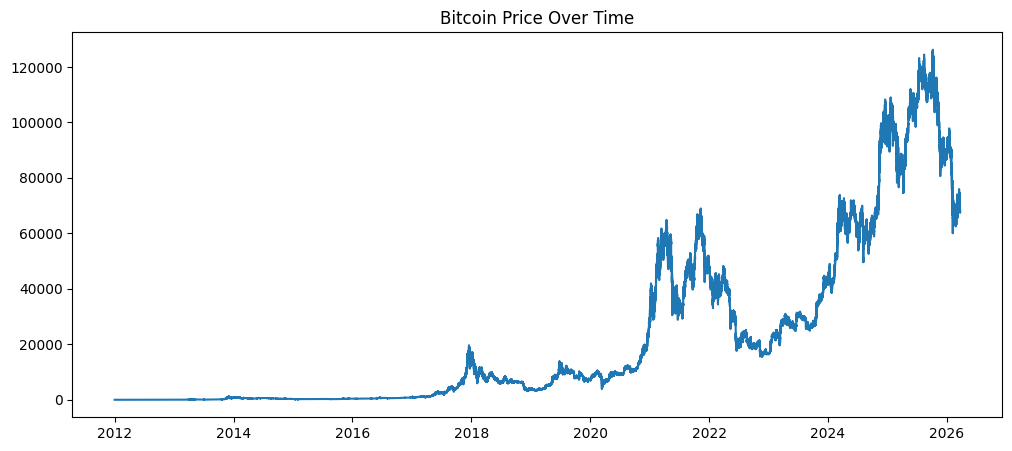

In [8]:
plt.figure(figsize=(12,5))
plt.plot(df['close'])
plt.title('Bitcoin Price Over Time')
plt.show()

In [10]:
daily = df.resample('D').mean()

daily.head()

,open,high,low,close,volume
timestamp,,,,,
2012-01-01,4.645697,4.645697,4.645697,4.645697,0.011919
2012-01-02,4.975000,4.975000,4.975000,4.975000,0.007014
2012-01-03,5.085500,5.085500,5.085500,5.085500,0.074365
2012-01-04,5.170250,5.170396,5.170250,5.170396,0.074468
2012-01-05,5.954292,5.954361,5.954292,5.954361,0.048839


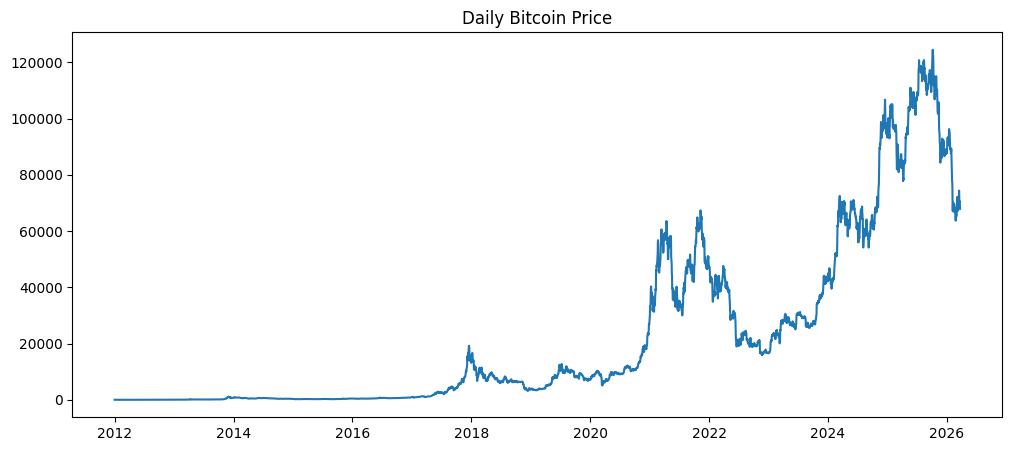

In [12]:
plt.figure(figsize=(12,5))
plt.plot(daily['close'])
plt.title('Daily Bitcoin Price')
plt.show()

In [14]:
df.describe()

,open,high,low,close,volume
count,7.479043e+06,7.479043e+06,7.479043e+06,7.479043e+06,7.479043e+06
mean,2.253264e+04,2.254065e+04,2.252444e+04,2.253265e+04,5.067648e+00
std,3.087111e+04,3.087953e+04,3.086262e+04,3.087113e+04,2.184568e+01
min,3.800000e+00,3.800000e+00,3.800000e+00,3.800000e+00,0.000000e+00
25%,4.500000e+02,4.500000e+02,4.499000e+02,4.500000e+02,2.095644e-02
50%,7.606600e+03,7.611590e+03,7.600670e+03,7.606660e+03,4.571012e-01
75%,3.518010e+04,3.520200e+04,3.515536e+04,3.517964e+04,2.870000e+00
max,1.262020e+05,1.262720e+05,1.261580e+05,1.262020e+05,5.853852e+03


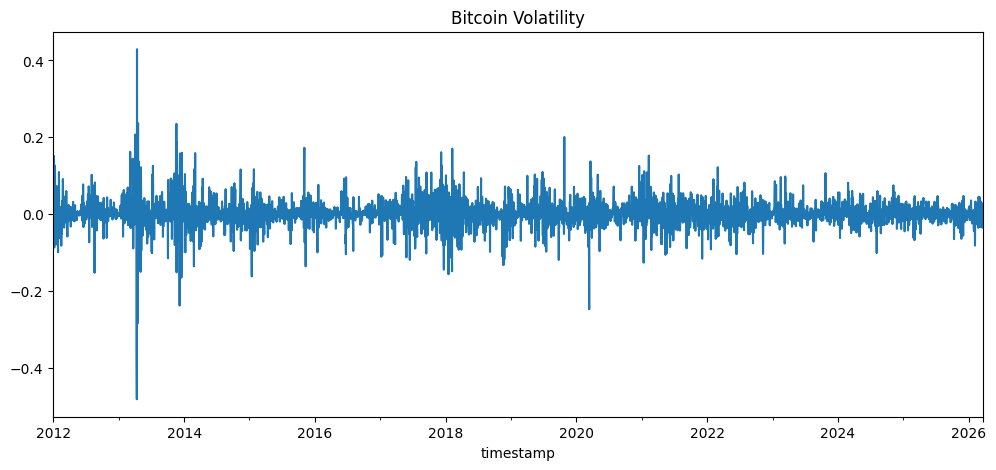

In [16]:
daily['returns'] = daily['close'].pct_change()

daily['returns'].plot(figsize=(12,5), title='Bitcoin Volatility')
plt.show()

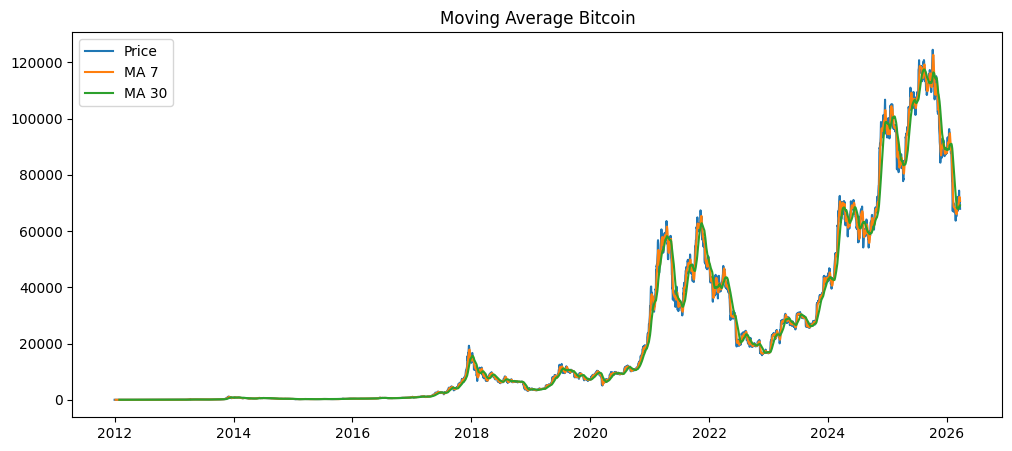

In [17]:
daily['ma7'] = daily['close'].rolling(7).mean()
daily['ma30'] = daily['close'].rolling(30).mean()

plt.figure(figsize=(12,5))
plt.plot(daily['close'], label='Price')
plt.plot(daily['ma7'], label='MA 7')
plt.plot(daily['ma30'], label='MA 30')
plt.legend()
plt.title('Moving Average Bitcoin')
plt.show()